In [1]:
import scipy
from dataset.dataset import *
from bandit_toy import *
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# plt.rc('font', family='Times New Roman',size=16)
args = bandit_get_args()
args.device = 'cpu'
marginal_prob_std_fn = functools.partial(marginal_prob_std, device=args.device)
score_model = Bandit_MlpScoreNet(input_dim=2, output_dim=2, marginal_prob_std=marginal_prob_std_fn, args=args).to(args.device)
score_model_pos = Bandit_MlpScoreNet(input_dim=2, output_dim=2, marginal_prob_std=marginal_prob_std_fn, args=args).to(args.device)


def energy_sample(env, ss, sample_per_state=1000, **kwargs):
    data, e = inf_train_gen(env,batch_size=1000*sample_per_state)
    ori_e = e
    e = e * ss

    index = np.random.choice(1000*sample_per_state, p=scipy.special.softmax(e).squeeze(), size=sample_per_state, replace=False)
    data = data[index]
    ori_e = ori_e[index]
    return data, ori_e

def binary_sample(env, ss, sample_per_state=1000, **kwargs):
    data, e = inf_train_gen(env,batch_size=sample_per_state)
    binary_label = np.random.rand(sample_per_state) < np.exp(e.reshape(-1))
    return data, binary_label.reshape(-1)

/nas/longleaf/home/weitongz/.conda/envs/RL/lib/python3.8/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
No module named 'flow'
/nas/longleaf/home/weitongz/.conda/envs/RL/lib/python3.8/site-packages/glfw/__init__.py:914: GLFWError: (65544) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
No module named 'carla'
pybullet build time: Nov 28 2023 23:51:11
/nas/longleaf/home/weitongz/.conda/envs/RL/lib/python3.8/site-packages/pybullet_envs/env_bases.py:8: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import parse_version
/nas/longleaf/home/weitongz/.conda/envs/RL/lib/python3.8/site-packages/pkg_resources/__init__.py:2832: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('mpl_toolkits')`.
Implementing

**************************
Namespace(alpha=3.0, debug=0, device='cuda', diffusion_steps=15, env='8gaussians', expid='default', method='CEP', save_model=1, seed=0)


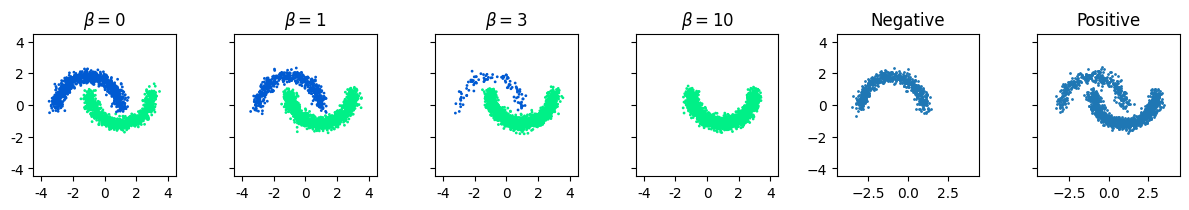

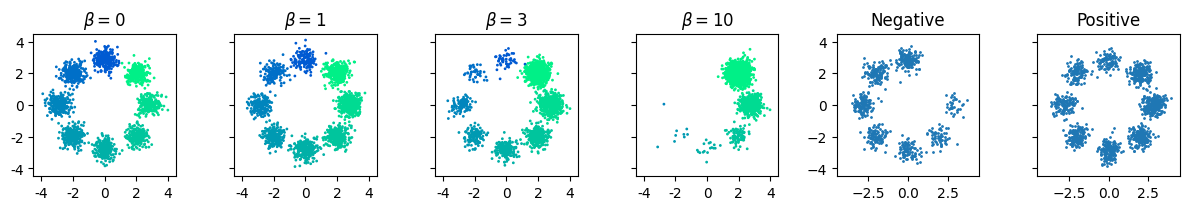

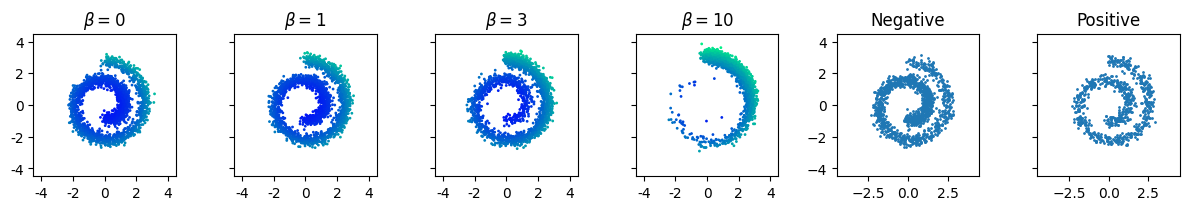

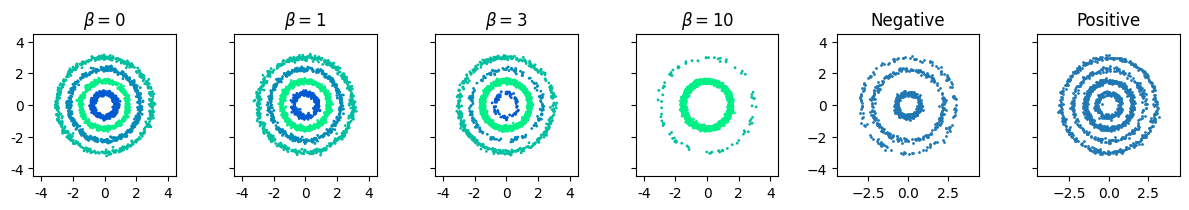

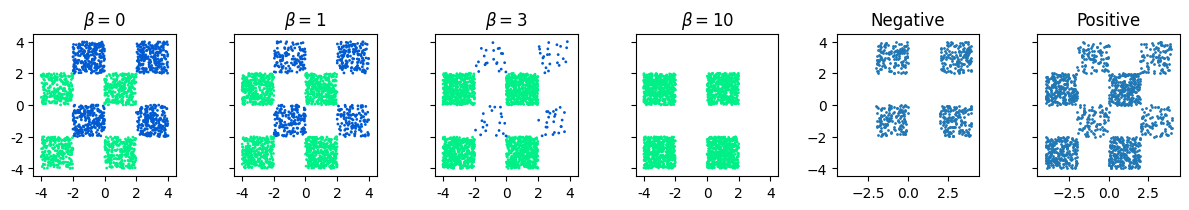

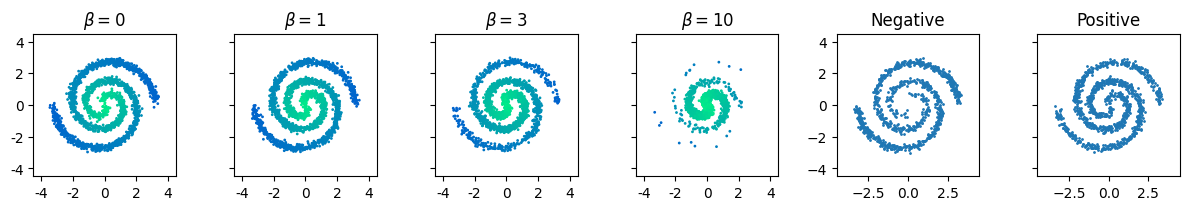

In [3]:
# scatter ground truth
for task in ["moons", "8gaussians", "swissroll","rings","checkerboard","2spirals"]:
    plt.figure(figsize=(12,3.0))
    ss = [0, 1, 3, 10]
    axes = []
    for i, s in enumerate(ss):
        plt.subplot(1, len(ss) + 2, i+1)
        data, e = energy_sample(task, s, sample_per_state=2000)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlim(-4.5,4.5)
        plt.ylim(-4.5,4.5)
        if i == 0:
            mappable = plt.scatter(data[:,0],data[:,1],s=1,c=e,cmap="winter",vmin=-1.6,vmax=0.1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        else:
            plt.scatter(data[:,0],data[:,1],s=1,c=e,cmap="winter",vmin=-1.6,vmax=0.1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[None, None, None, None, None])
        axes.append(plt.gca())
        plt.xticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        plt.title(r'$\beta={}$'.format(s))
    plt.subplot(1, len(ss) + 2, len(ss) + 1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-4.5,4.5)
    plt.ylim(-4.5,4.5)
    data, e = binary_sample(task, s, sample_per_state=2000)
    plt.scatter(data[e == 0,0], data[e == 0,1], s=1, rasterized=True)
    plt.title(r'Negative')
    plt.subplot(1, len(ss) + 2, len(ss) + 2)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-4.5,4.5)
    plt.ylim(-4.5,4.5)
    plt.scatter(data[e == 1,0], data[e == 1,1], s=1, rasterized=True)
    plt.title(r'Positive')
    plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[None, None, None, None, None])
    plt.tight_layout()
    plt.savefig(f"scatter_{task}.pdf", bbox_inches='tight', pad_inches=0.1)



[]

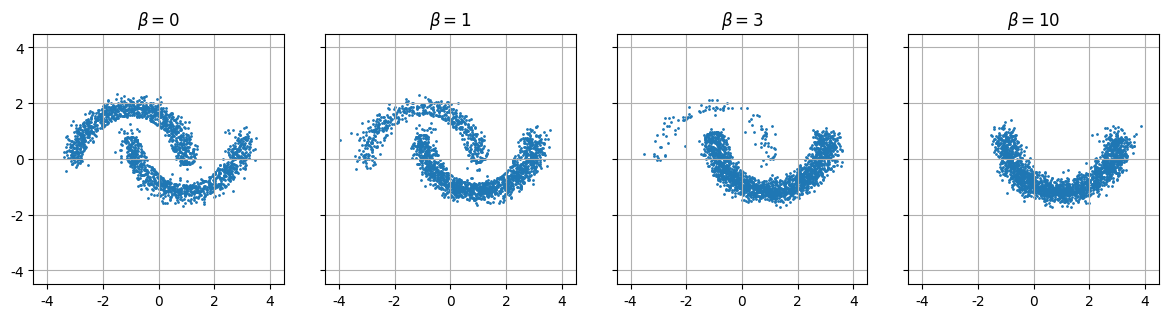

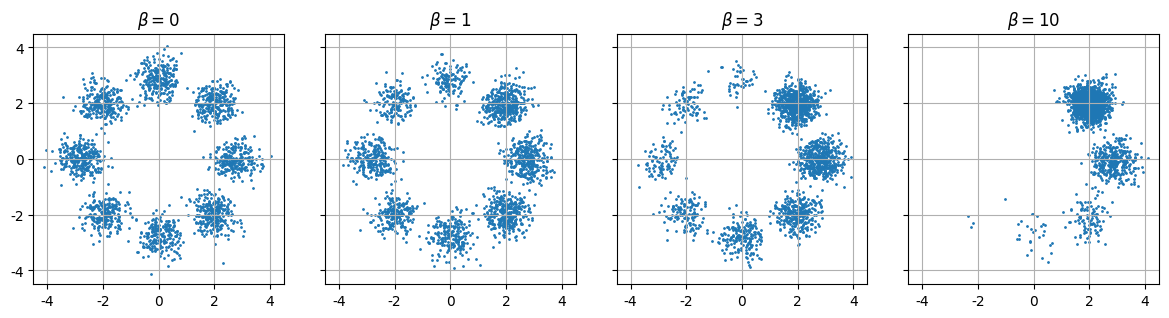

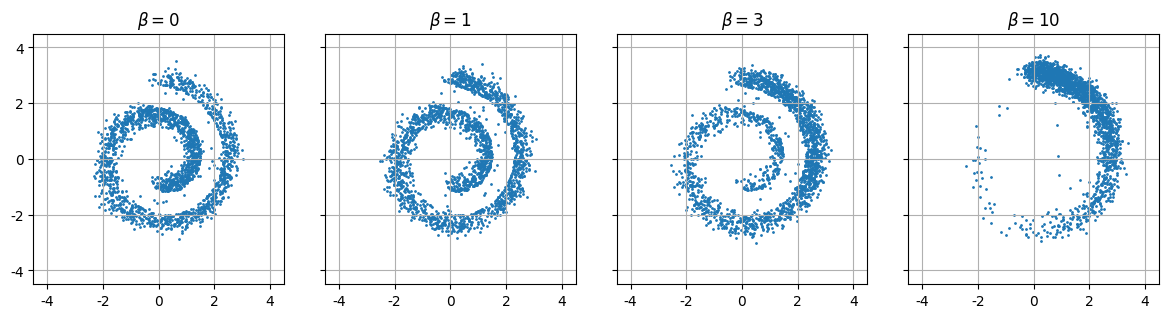

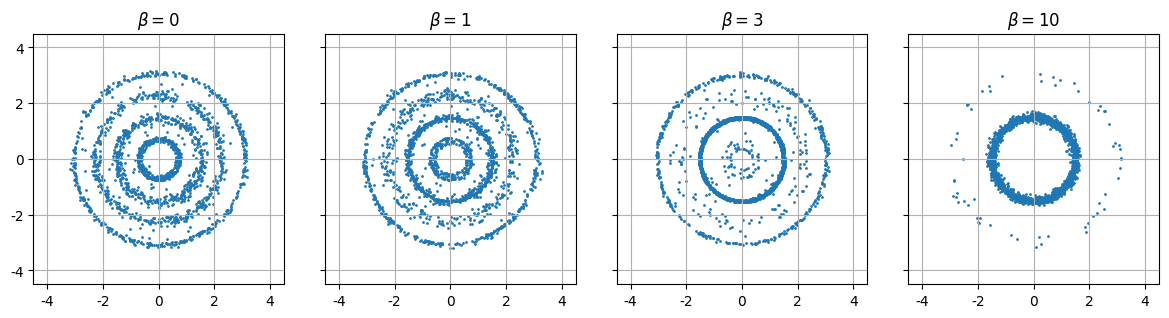

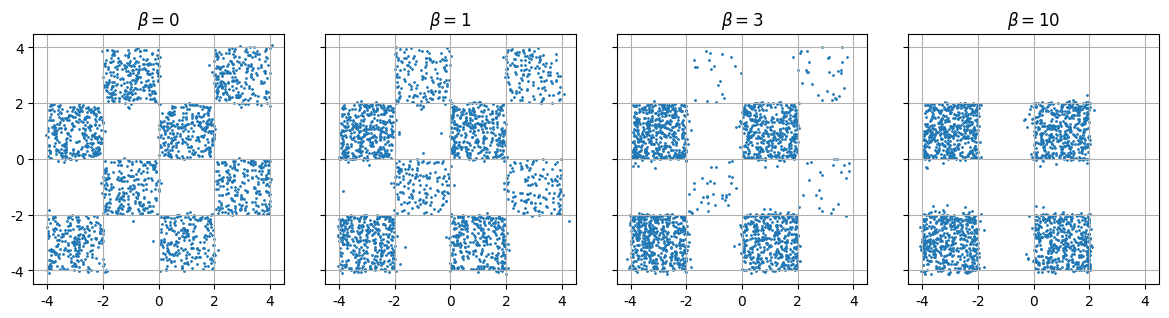

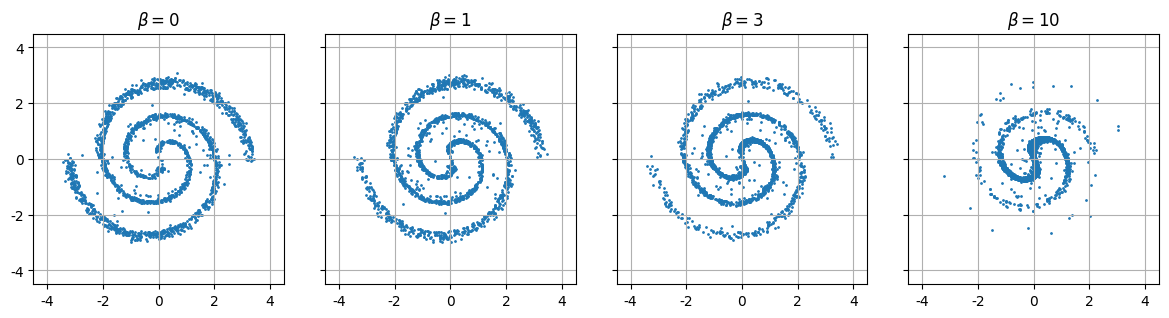

In [16]:
# for task in ["8gaussians", "moons", "swissroll"]:
for task in ["moons", "8gaussians", "swissroll","rings","checkerboard","2spirals"]:
    plt.figure(figsize=(12,3.0))
    ss = [0, 1, 3, 10]
    axes = []
    for i, s in enumerate(ss):
        plt.subplot(1, len(ss), i+1)
        ckpt = torch.load("./models/{}0alpha{}/ckpt300.pth".format(task, s), map_location=args.device)
        score_model.load_state_dict(ckpt)
        data = score_model.sample(None, sample_per_state=2000, diffusion_steps=25)

        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlim(-4.5,4.5)
        plt.ylim(-4.5,4.5)
        if i == 0:
            mappable = plt.scatter(data[:,0],data[:,1],s=1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        else:
            plt.scatter(data[:,0],data[:,1],s=1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[None, None, None, None, None])
        axes.append(plt.gca())
        plt.xticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        plt.title(r'$ \beta ={}$'.format(s))
        plt.grid(True)
    plt.tight_layout()
plt.plot()

[]

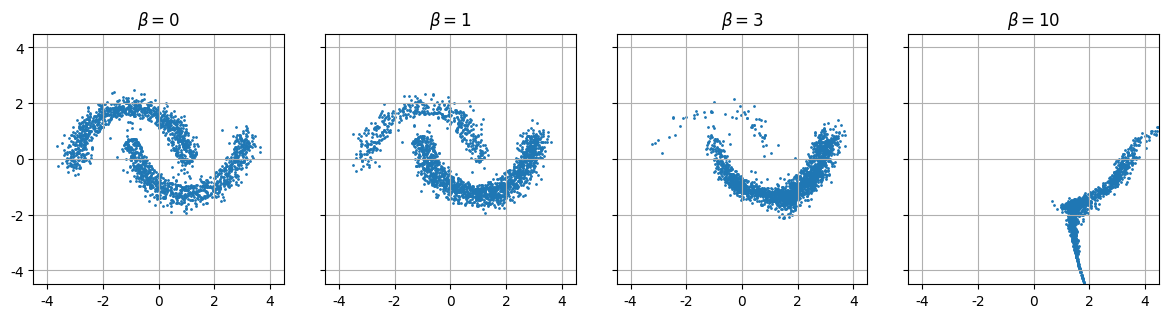

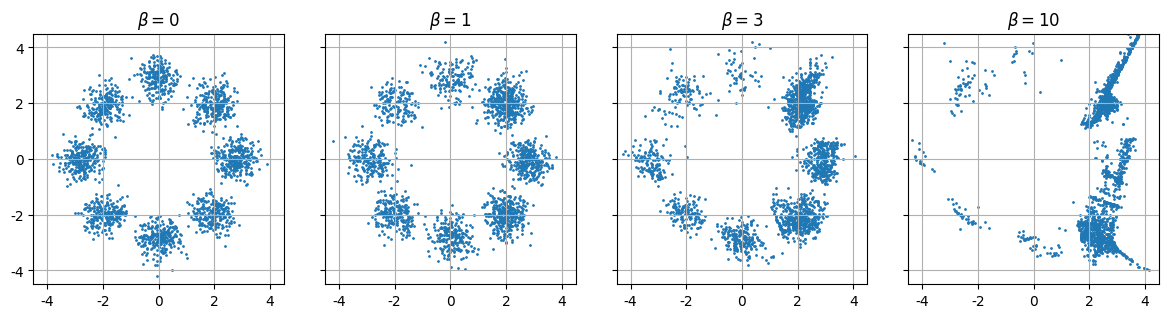

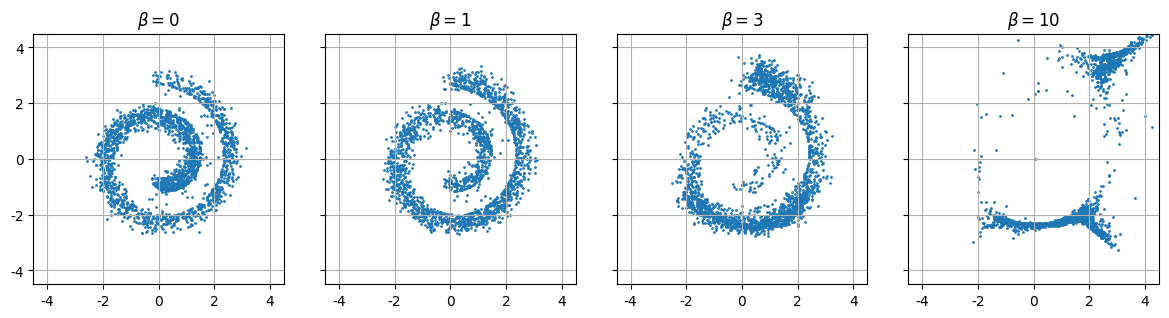

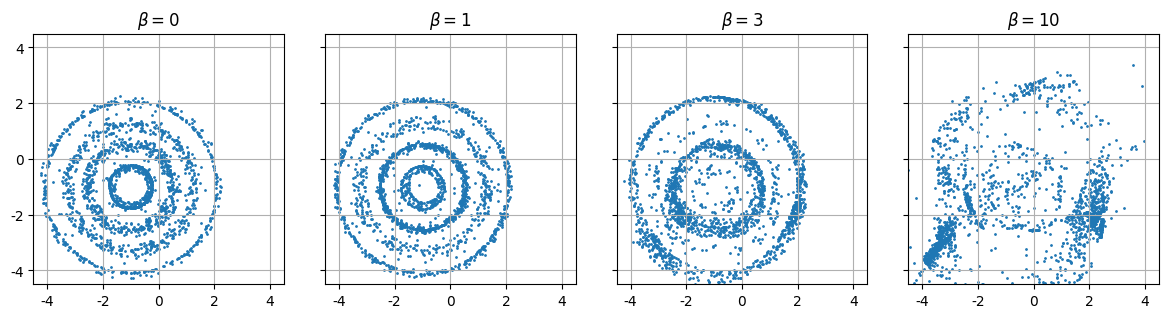

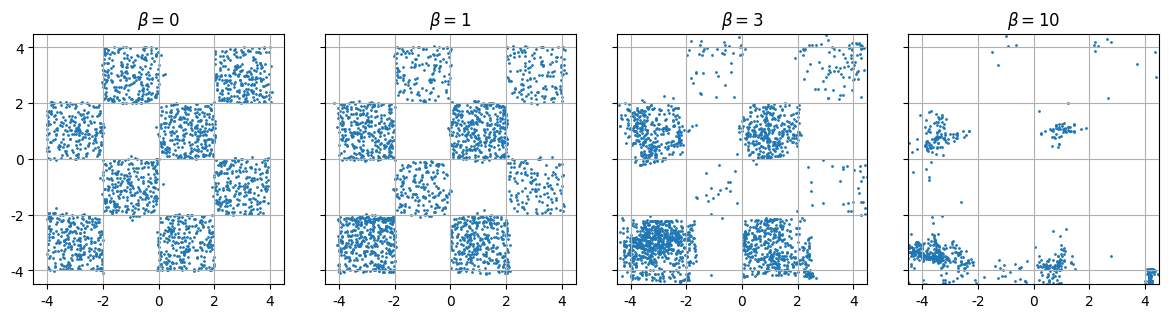

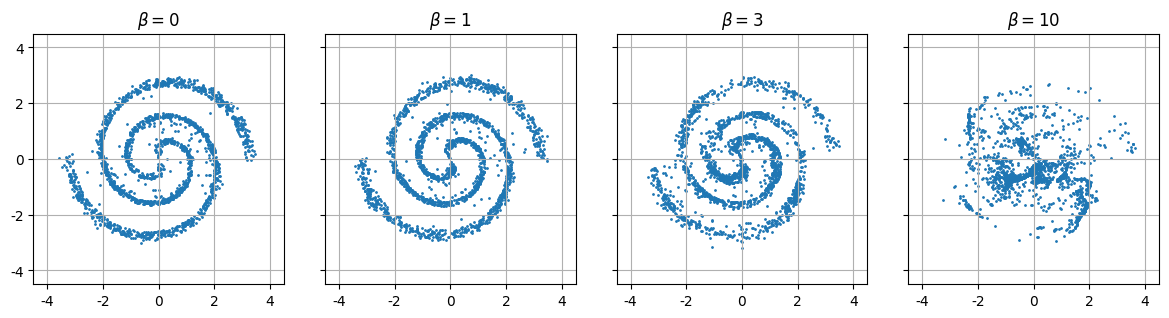

In [3]:
# for task in ["8gaussians", "moons", "swissroll"]:
from diffusion_SDE import dpm_solver_pytorch

def guided_wrapper_fn(gamma):
     return lambda x, t: (1 - gamma) * score_model.forward_dmp_wrapper_fn(x, t) + gamma * score_model_pos.forward_dmp_wrapper_fn(x, t)
def guided_dpm_solver(gamma):
    return dpm_solver_pytorch.DPM_Solver(guided_wrapper_fn(gamma), score_model.noise_schedule)
def dpm_wrapper_sample(gamma, dim, batch_size, **kwargs):
    with torch.no_grad():
        init_x = torch.randn(batch_size, dim, device=score_model.device)
        return guided_dpm_solver(gamma).sample(init_x, **kwargs).cpu().numpy()
    
def cfg_sample(gamma, states=None, sample_per_state=16, diffusion_steps=15):
    score_model.eval()
    score_model_pos.eval()
    with torch.no_grad():
        results = dpm_wrapper_sample(gamma, score_model.output_dim, batch_size=sample_per_state, steps=diffusion_steps, order=2, method='multistep')
        actions = results[:, :]
    score_model.train()
    score_model_pos.train()
    return actions

for task in ["moons", "8gaussians", "swissroll","rings","checkerboard","2spirals"]:
    plt.figure(figsize=(12,3.0))
    ss = [0, 1, 3, 10]
    axes = []
    for i, s in enumerate(ss):
        plt.subplot(1, len(ss), i+1)
        ckpt_reg = torch.load("./models/{}0/ckpt350reg.pth".format(task), map_location=args.device)
        ckpt_pos = torch.load("./models/{}0/ckpt350pos.pth".format(task), map_location=args.device)

        score_model.load_state_dict(ckpt_reg)
        score_model_pos.load_state_dict(ckpt_pos)

         
        data = cfg_sample(s, None, sample_per_state=2000, diffusion_steps=25)

        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlim(-4.5,4.5)
        plt.ylim(-4.5,4.5)
        if i == 0:
            mappable = plt.scatter(data[:,0],data[:,1],s=1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        else:
            plt.scatter(data[:,0],data[:,1],s=1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[None, None, None, None, None])
        axes.append(plt.gca())
        plt.xticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        plt.title(r'$ \beta ={}$'.format(s))
        plt.grid(True)
    plt.tight_layout()
plt.plot()